Pr2. Symulacja gdy Gamma jest ciągła/jednostajna. Bierzemy G = [G_1,G_2];, G_i i.i.d. N(0,sigma^2).
alpha < 0; A \ S_{alpha/2} (sigma = (cos pi * alpha / 4)^{2/alpha}, beta = 1, mi = 0)
Wtedy sqrt(A)G = [sqrt(A) G_1, sqrt(A) G_2]' jest wektorem alpha-stabilnym o mierze Gamma jednostajnej tzn. A \subseteq S_2 Gamma(A) \prop |A|

Pr1. Estymacja Gamma
lim r->inf P(X \in Cone(A), |X| > r)/P(|X| > r) = Gamma(A)/Gamma(S_d), gdzie Cone(A) - minimalny "nieskonczony trojkat" o rogu srodku ukl. wsp. zaw. A (A leży na okręgu)

EstGamma(A) \prop #{i:|X_i| \in Cone(A), |X_i|> r}/#{i:|X_i|>r}

Rozważać phi_j = [(j-1) 2 pi / n, 2 pi / n =], j = 1,...,n
A_j = {[cos x, sinx]:x \in phi_j}

EstGamma(A) \prop #{i:arctan2(X_i) \in phi_j, |X_i| > r} / # {|X_i| > r}, gdzie (arctan2 - 2arg arctan)

Bierz różne kąty i spr. ile obs. w danym kącie leży. Zrob Histogram gdzie jedna os X to brzegi zbiorow (2 pi /n, 2 2 pi /n, ..., 2 pi) a wartosc wyliczona wyzej (EstGamma(A_1))

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import scipy.stats as stats
import seaborn as sns
from tqdm import tqdm # progress bar
import math

np.random.seed(42)

In [21]:
def get_random_a_stable(alpha, beta, gamma, delta):
    theta = np.random.uniform()*math.pi - math.pi/2
    theta_0 = np.arctan(beta*np.tan(math.pi*alpha/2))/alpha
    W = np.random.exponential()

    if alpha == 1:
        Z = 2/math.pi * ( (math.pi/2 + beta*theta)*np.tan(theta) - beta*np.log((math.pi/2 * W*np.cos(theta)) / (math.pi/2 + beta*theta)) )
        return gamma*Z + (delta + beta * 2/math.pi * gamma * np.log(gamma))
    else:
        Z = np.sin(alpha*(theta_0 + theta)) / ((np.cos(alpha*theta_0)*np.cos(theta))**(1/alpha)) * ( np.cos(alpha*theta_0 + (alpha - 1)*theta) / W )**((1 - alpha)/alpha)
        return gamma*Z + delta

In [22]:
def generate_random_gaussian_vectors(num_vectors, vector_length, scale=1.0):
    return np.random.normal(scale=scale, size=(num_vectors, vector_length))

In [23]:
def get_A(alpha):
    return get_random_a_stable(alpha=alpha/2, beta=1, gamma=(np.cos(np.pi*alpha/4))**(2/alpha), delta=0)

In [31]:
def cone_A(A):
    G = generate_random_gaussian_vectors(num_vectors=1, vector_length=10, scale=1.0)
    X = np.sqrt(A)*G
    return X

In [ ]:

# Rozważać phi_j = [(j-1) 2 pi / n, 2 pi / n =], j = 1,...,n
# A_j = {[cos x, sinx]:x \in phi_j}

# EstGamma(A) \prop #{i:arctan2(X_i) \in phi_j, |X_i| > r} / # {|X_i| > r}, gdzie (arctan2 - 2arg arctan)

# Bierz różne kąty i spr. ile obs. w danym kącie leży. Zrob Histogram gdzie jedna os X to brzegi zbiorow (2 pi /n, 2 2 pi /n, ..., 2 pi) a wartosc wyliczona wyzej (EstGamma(A_1))
num = 4
phi_j = np.linspace(0, 2*np.pi, num=num+1)[:-1] 
A_j = np.array([[np.cos(phi), np.sin(phi)] for phi in phi_j])

def est_spectral_measure(A, r):
    count = 0
    for _ in range(10000):
        X = cone_A(A) # ConeA is set of ra, a \in A, r > 0
        if np.linalg.norm(X) > r:
            count += 1
            angle = np.arctan2(X[0,1], X[0,0]) % (2*np.pi)  # Get angle in [0, 2pi)
            for j in range(num):
                if phi_j[j] <= angle < phi_j[j] + 2*np.pi/num:
                    A_j[j] += 1
                    break
    return A_j / count

Estimated Spectral Measure for r=0.5: [[0.2503 0.2502]
 [0.2519 0.252 ]
 [0.2518 0.2519]
 [0.246  0.2459]]


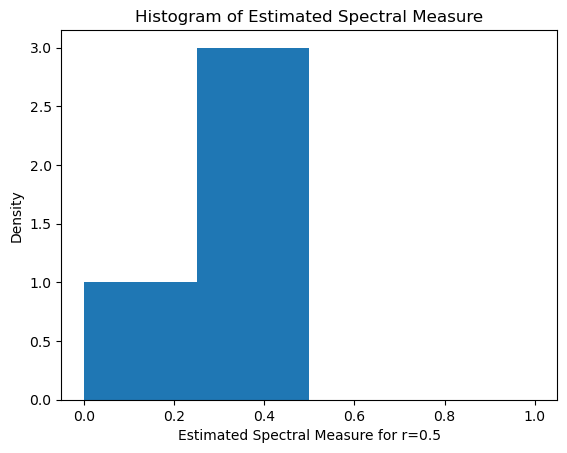

Estimated Spectral Measure for r=1.0: [[0.5037 0.5036]
 [0.4924 0.4925]
 [0.505  0.5051]
 [0.4989 0.4988]]


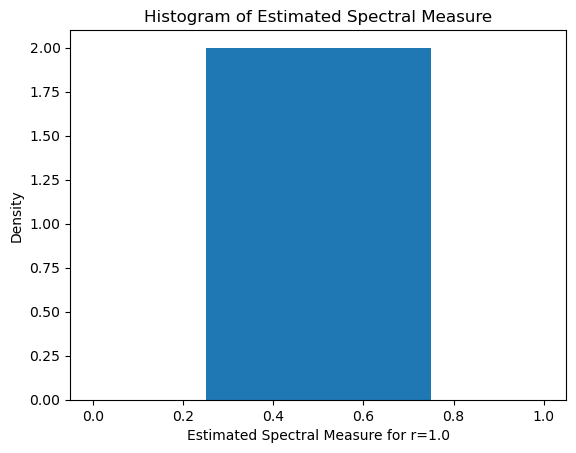

Estimated Spectral Measure for r=1.5: [[0.75257526 0.75247525]
 [0.74657466 0.74667467]
 [0.75107511 0.75117512]
 [0.749975   0.74987499]]


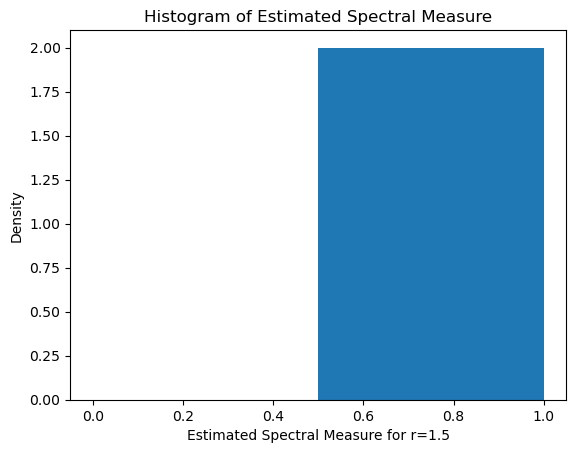

In [33]:
A = get_A(alpha=1.5)
for r in [0.5, 1.0, 1.5]:
    estimated_measure = est_spectral_measure(A, r)
    print(f"Estimated Spectral Measure for r={r}:", estimated_measure)
    plt.hist(estimated_measure.flatten(), bins=num, range=(0, 1), density=True)
    plt.xlabel(f'Estimated Spectral Measure for r={r}')
    plt.ylabel('Density')
    plt.title('Histogram of Estimated Spectral Measure')
    plt.show()  

In [ ]:
# def est_spectral_measure(X, num_directions=1000):
#     d = X.shape[1]
#     directions = generate_random_gaussian_vectors(num_directions, d)
#     directions /= np.linalg.norm(directions, axis=1)[:, np.newaxis]  # Normalize to unit vectors
#     projections = X @ directions.T  # Project X onto each direction
#     return projections

In [9]:
d = 10
A = get_A(alpha=1.5)
G = generate_random_gaussian_vectors(num_vectors=1, vector_length=d, scale=1.0)
X = np.sqrt(A)*G
print(X)

[[-1.32208644 -0.43097283 -0.77629802  0.24085909 -0.69596725 -1.08247914
   1.12336619 -0.17304928  0.0517579  -1.09201739]]


In [ ]:
# #Check if spectral measure (Gamma) of X is uniform on the unit sphere
# def spectral_measure(X):
#     norms = np.linalg.norm(X, axis=1)
#     unit_vectors = X / norms[:, np.newaxis]
#     return unit_vectors
# # def is_uniform_on_sphere(X, num_samples=1000):
# #     norms = np.linalg.norm(X, axis=1)
# #     unit_vectors = X / norms[:, np.newaxis]
    
# #     # Check if the distribution of unit vectors is uniform on the sphere
# #     # We can use a chi-squared test for uniformity
# #     expected_count = num_samples / len(unit_vectors)
# #     observed_count, _ = np.histogramdd(unit_vectors, bins=10)
    
# #     chi2_statistic, p_value = stats.chisquare(observed_count.flatten(), f_exp=expected_count)
    
# #     return p_value > 0.05  # Return True if we fail to reject the null hypothesis of uniformity

In [12]:
#Check if characteristic function of X is of the form exp(-2**{alpha/2}*sigma**alpha*|theta|**alpha)
def characteristic_function(theta, alpha, sigma):
    return np.exp(-2**(alpha/2) * sigma**alpha * np.linalg.norm(theta)**alpha)

In [ ]:
# is_uniform = is_uniform_on_sphere(X, num_samples=1000)
# print(f"Is the spectral measure of X uniform on the unit sphere? {is_uniform}")

absA = np.abs(A)
gammaX = spectral_measure(X)
print(f"Spectral measure (Gamma) of X: {gammaX}")
print(f"Absolute value of A: {absA}")

theta = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])
phi = characteristic_function(theta=theta, alpha=1.5, sigma=np.sqrt(A))
print(f"Characteristic function phi(theta) for theta={theta}: {phi}")

phi2 = np.mean(np.exp(1j * np.dot(theta, X.flatten())))

print(f"Empirical characteristic function phi(theta) for theta={theta}: {phi2}")

Spectral measure (Gamma) of X: 1.0
Absolute value of A: 0.5874661948420519
Characteristic function phi(theta) for theta=[1 0 0 0 0 0 0 0 0 0]: 0.3235113658465647
Empirical characteristic function phi(theta) for theta=[1 0 0 0 0 0 0 0 0 0]: (0.24615374278048452-0.9692307954843156j)


In [ ]:
#VERIFY